📂 Found existing model. Skipping training.


C:\Users\pesam\AppData\Local\Temp\ipykernel_15108\2927728610.py:61: DeprecationWarning: Please import `shift` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  return interpolation.shift(img, [sy, sx], mode='constant')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step


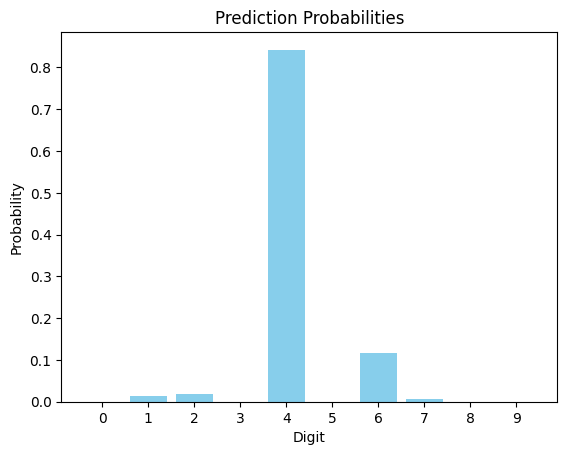

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


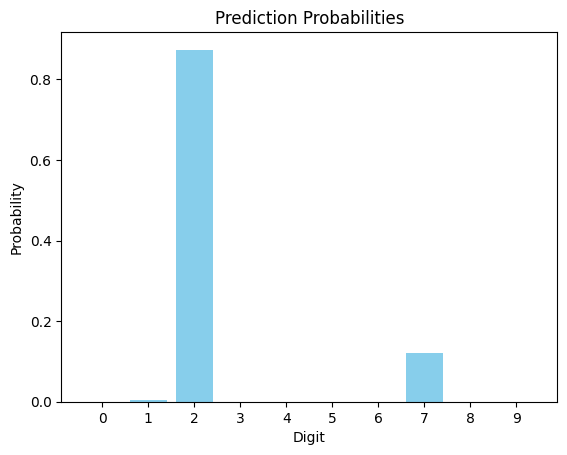

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


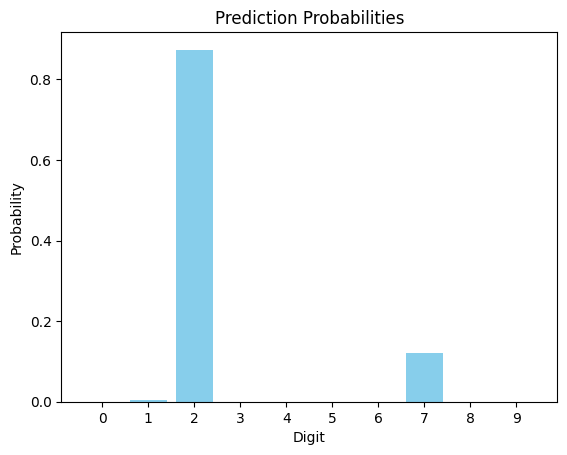

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


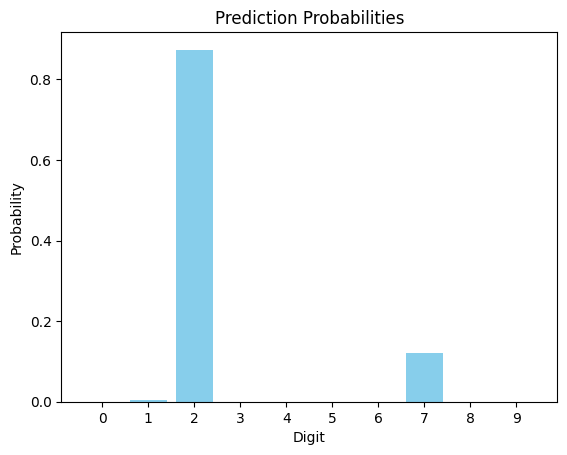

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


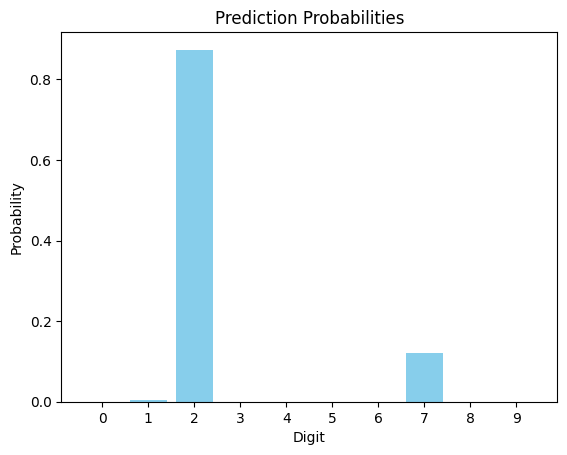

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


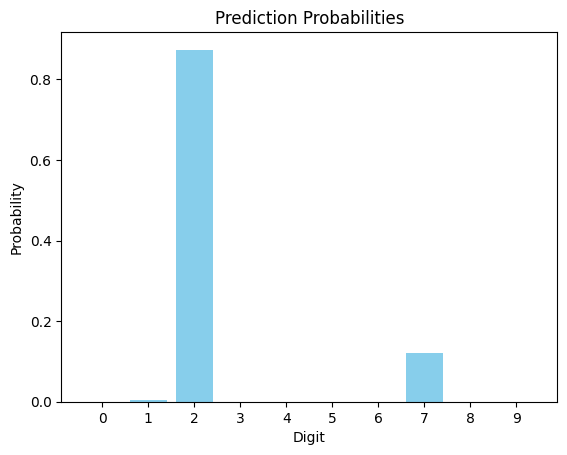

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


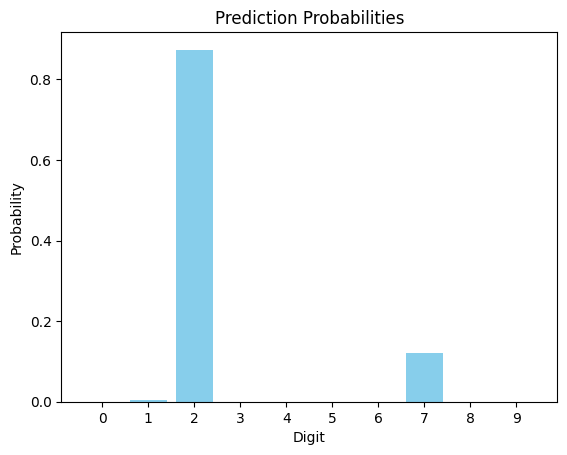

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


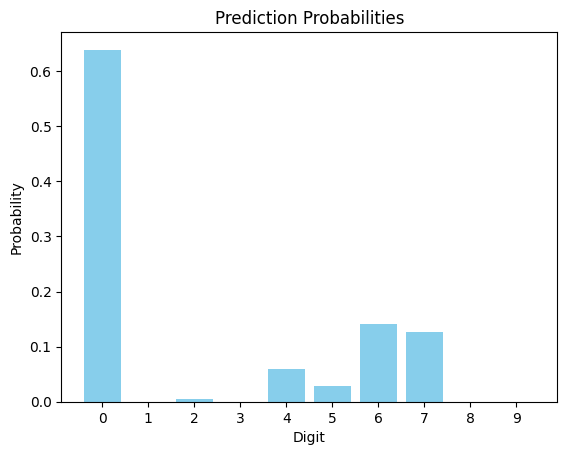

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


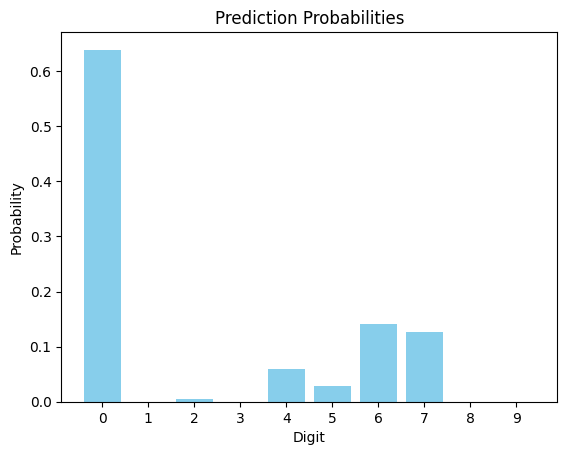

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


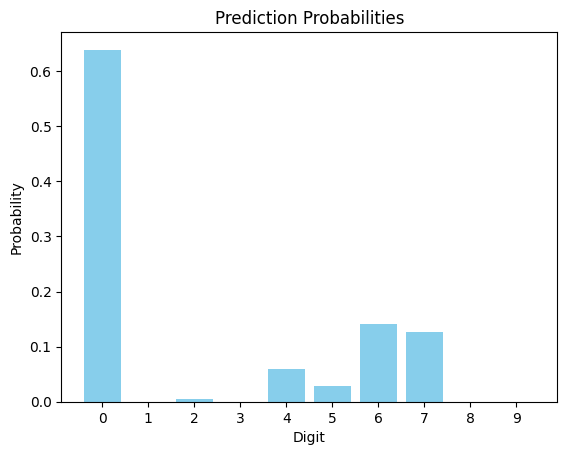

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


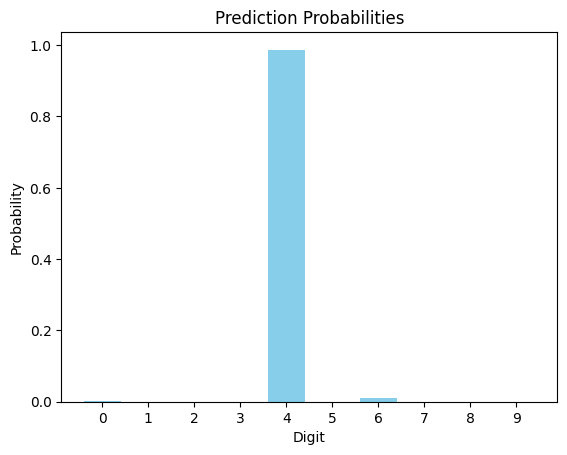

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


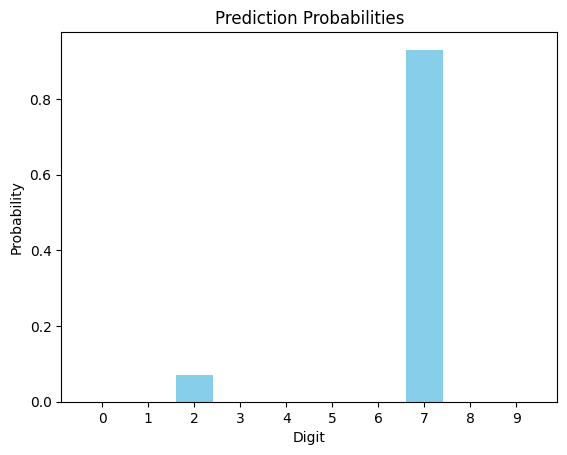

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


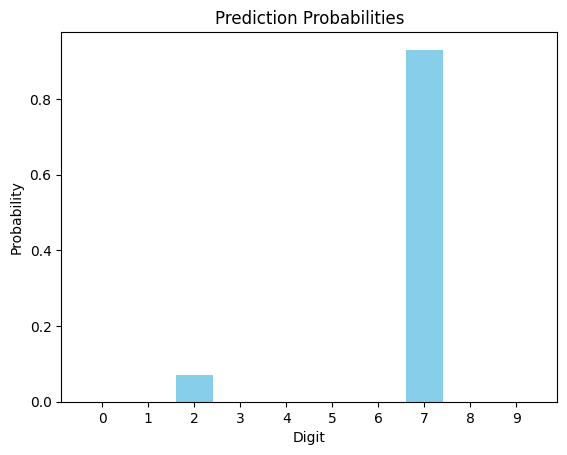

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


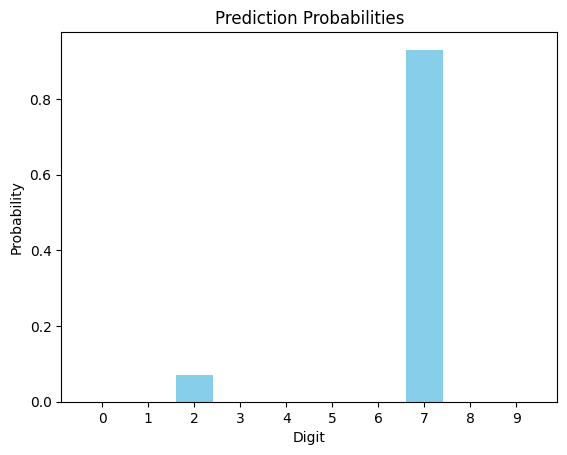

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


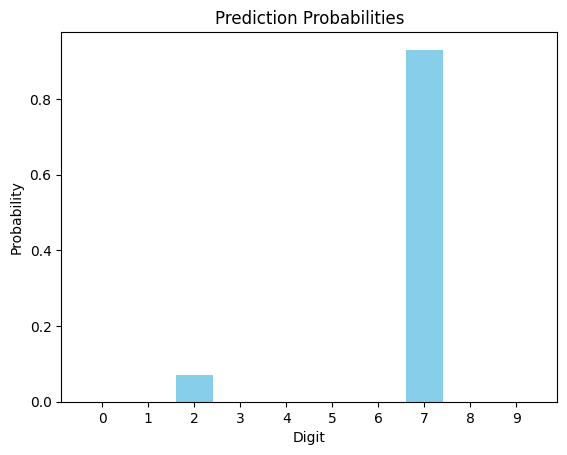

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


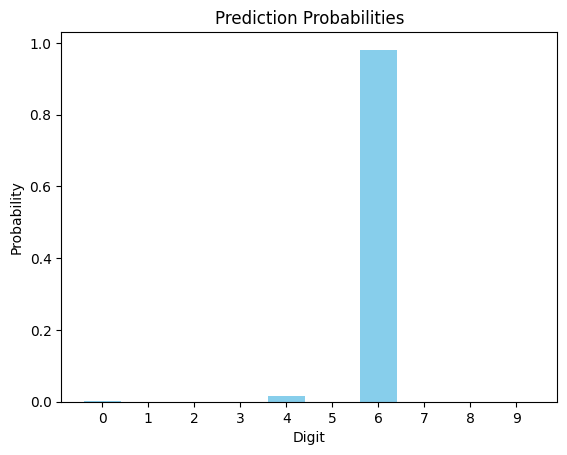

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


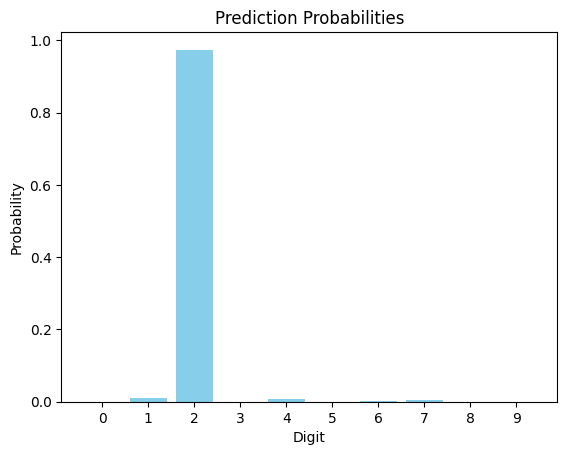

In [ ]:
import os
import numpy as np
import tkinter as tk
from PIL import Image, ImageOps, ImageGrab
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from scipy.ndimage import interpolation
import matplotlib.pyplot as plt

MODEL_PATH = "digit_recognition_model.h5"

# ---------------------------
# Step 1: Train Model (if not saved already)
# ---------------------------
if not os.path.exists(MODEL_PATH):
    print("🔄 Training model... This will take some time.")
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),  # Helps prevent overfitting
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    model.fit(x_train, y_train, epochs=15, batch_size=128,
              validation_split=0.1, verbose=1)

    model.save(MODEL_PATH)
    print("✅ Model trained and saved as", MODEL_PATH)
else:
    print("📂 Found existing model. Skipping training.")

# Load the model
model = load_model(MODEL_PATH)

# ---------------------------
# Step 2: Preprocessing Helpers
# ---------------------------

def get_best_shift(img):
    cy, cx = np.array(np.where(img > 0)).mean(axis=1)
    rows, cols = img.shape
    shiftx = np.round(cols/2.0 - cx).astype(int)
    shifty = np.round(rows/2.0 - cy).astype(int)
    return shiftx, shifty

def shift(img, sx, sy):
    return interpolation.shift(img, [sy, sx], mode='constant')

def preprocess(img):
    img = img.convert("L")          # Convert to grayscale
    img = ImageOps.invert(img)      # Invert: black digit on white
    img = img.resize((28, 28))      # Resize to MNIST format
    img = np.array(img)

    # Threshold to remove noise
    img = (img > 20) * 255

    img = img.astype("float32") / 255.0  # Normalize

    if img.sum() > 0:
        shiftx, shifty = get_best_shift(img)
        img = shift(img, shiftx, shifty)

    return img.reshape(1, 28, 28, 1)

# ---------------------------
# Step 3: GUI App
# ---------------------------

class DigitApp:
    def __init__(self, root):  # ✅ Fixed: __init, not _init
        self.root = root
        self.root.title("Handwritten Digit Recognition")

        # Canvas to draw digit
        self.canvas = tk.Canvas(root, width=200, height=200, bg="white")
        self.canvas.grid(row=0, column=0, columnspan=2)
        self.canvas.bind("<B1-Motion>", self.paint)

        # Buttons
        tk.Button(root, text="Predict", command=self.predict_digit).grid(row=1, column=0)
        tk.Button(root, text="Clear", command=self.clear_canvas).grid(row=1, column=1)

        # Label for results
        self.result_label = tk.Label(root, text="Draw a digit", font=("Arial", 18))
        self.result_label.grid(row=2, column=0, columnspan=2)

    def paint(self, event):
        x1, y1 = (event.x - 8), (event.y - 8)
        x2, y2 = (event.x + 8), (event.y + 8)
        self.canvas.create_oval(x1, y1, x2, y2, fill="black")

    def clear_canvas(self):
        self.canvas.delete("all")
        self.result_label.config(text="Draw a digit")

    def predict_digit(self):
        # Capture the drawn image from canvas
        x = self.root.winfo_rootx() + self.canvas.winfo_x()
        y = self.root.winfo_rooty() + self.canvas.winfo_y()
        x1 = x + self.canvas.winfo_width()
        y1 = y + self.canvas.winfo_height()
        img = ImageGrab.grab().crop((x, y, x1, y1))

        # Preprocess the image
        img = preprocess(img)

        # Predict using the model
        probs = model.predict(img)[0]
        pred = np.argmax(probs)
        confidence = probs[pred] * 100

        if confidence < 70:
            self.result_label.config(text="Unclear, try again")
        else:
            self.result_label.config(text=f"Prediction: {pred} ({confidence:.2f}%)")

        # Display bar chart of probabilities
        digits = list(range(10))
        plt.bar(digits, probs, color="skyblue")
        plt.xticks(digits)
        plt.xlabel("Digit")
        plt.ylabel("Probability")
        plt.title("Prediction Probabilities")
        plt.show()
        plt.close()

# ---------------------------
# Step 4: Run the GUI
# ---------------------------
if __name__ == "__main__":
    root = tk.Tk()
    app = DigitApp(root)
    root.mainloop()